        PM2.5        PM10        NO2        SO2        CO          O3  \
0  118.616634   90.350513  29.862040  54.470834  1.758788   65.108973   
1  285.707149  225.922360  28.462986  64.141149  2.435754   76.280992   
2  222.278243  351.719418  91.094185  21.536496  2.304467  129.636635   
3  183.610960  298.245457  28.706889  50.740180  0.546310   57.600614   
4   55.245406  326.493236  30.835224  46.596187  0.532823  131.750956   

          AQI  
0  148.646853  
1  287.734513  
2  323.255683  
3  234.805409  
4  188.279086  

Missing Values:
 PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
AQI      0
dtype: int64


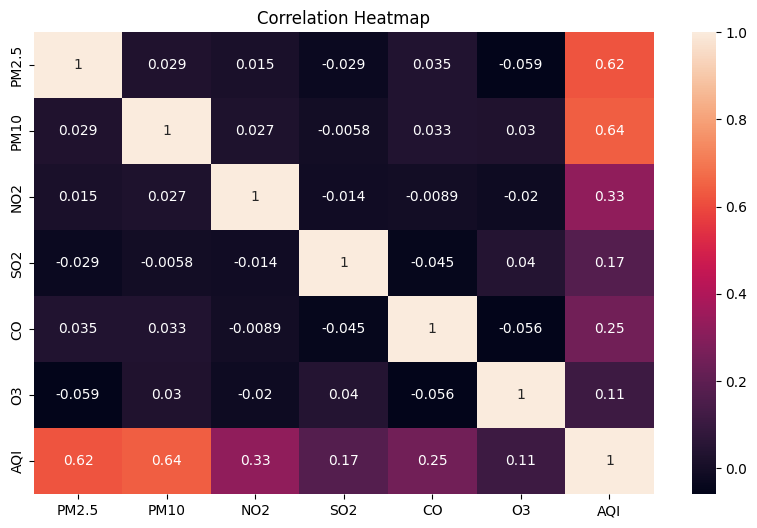

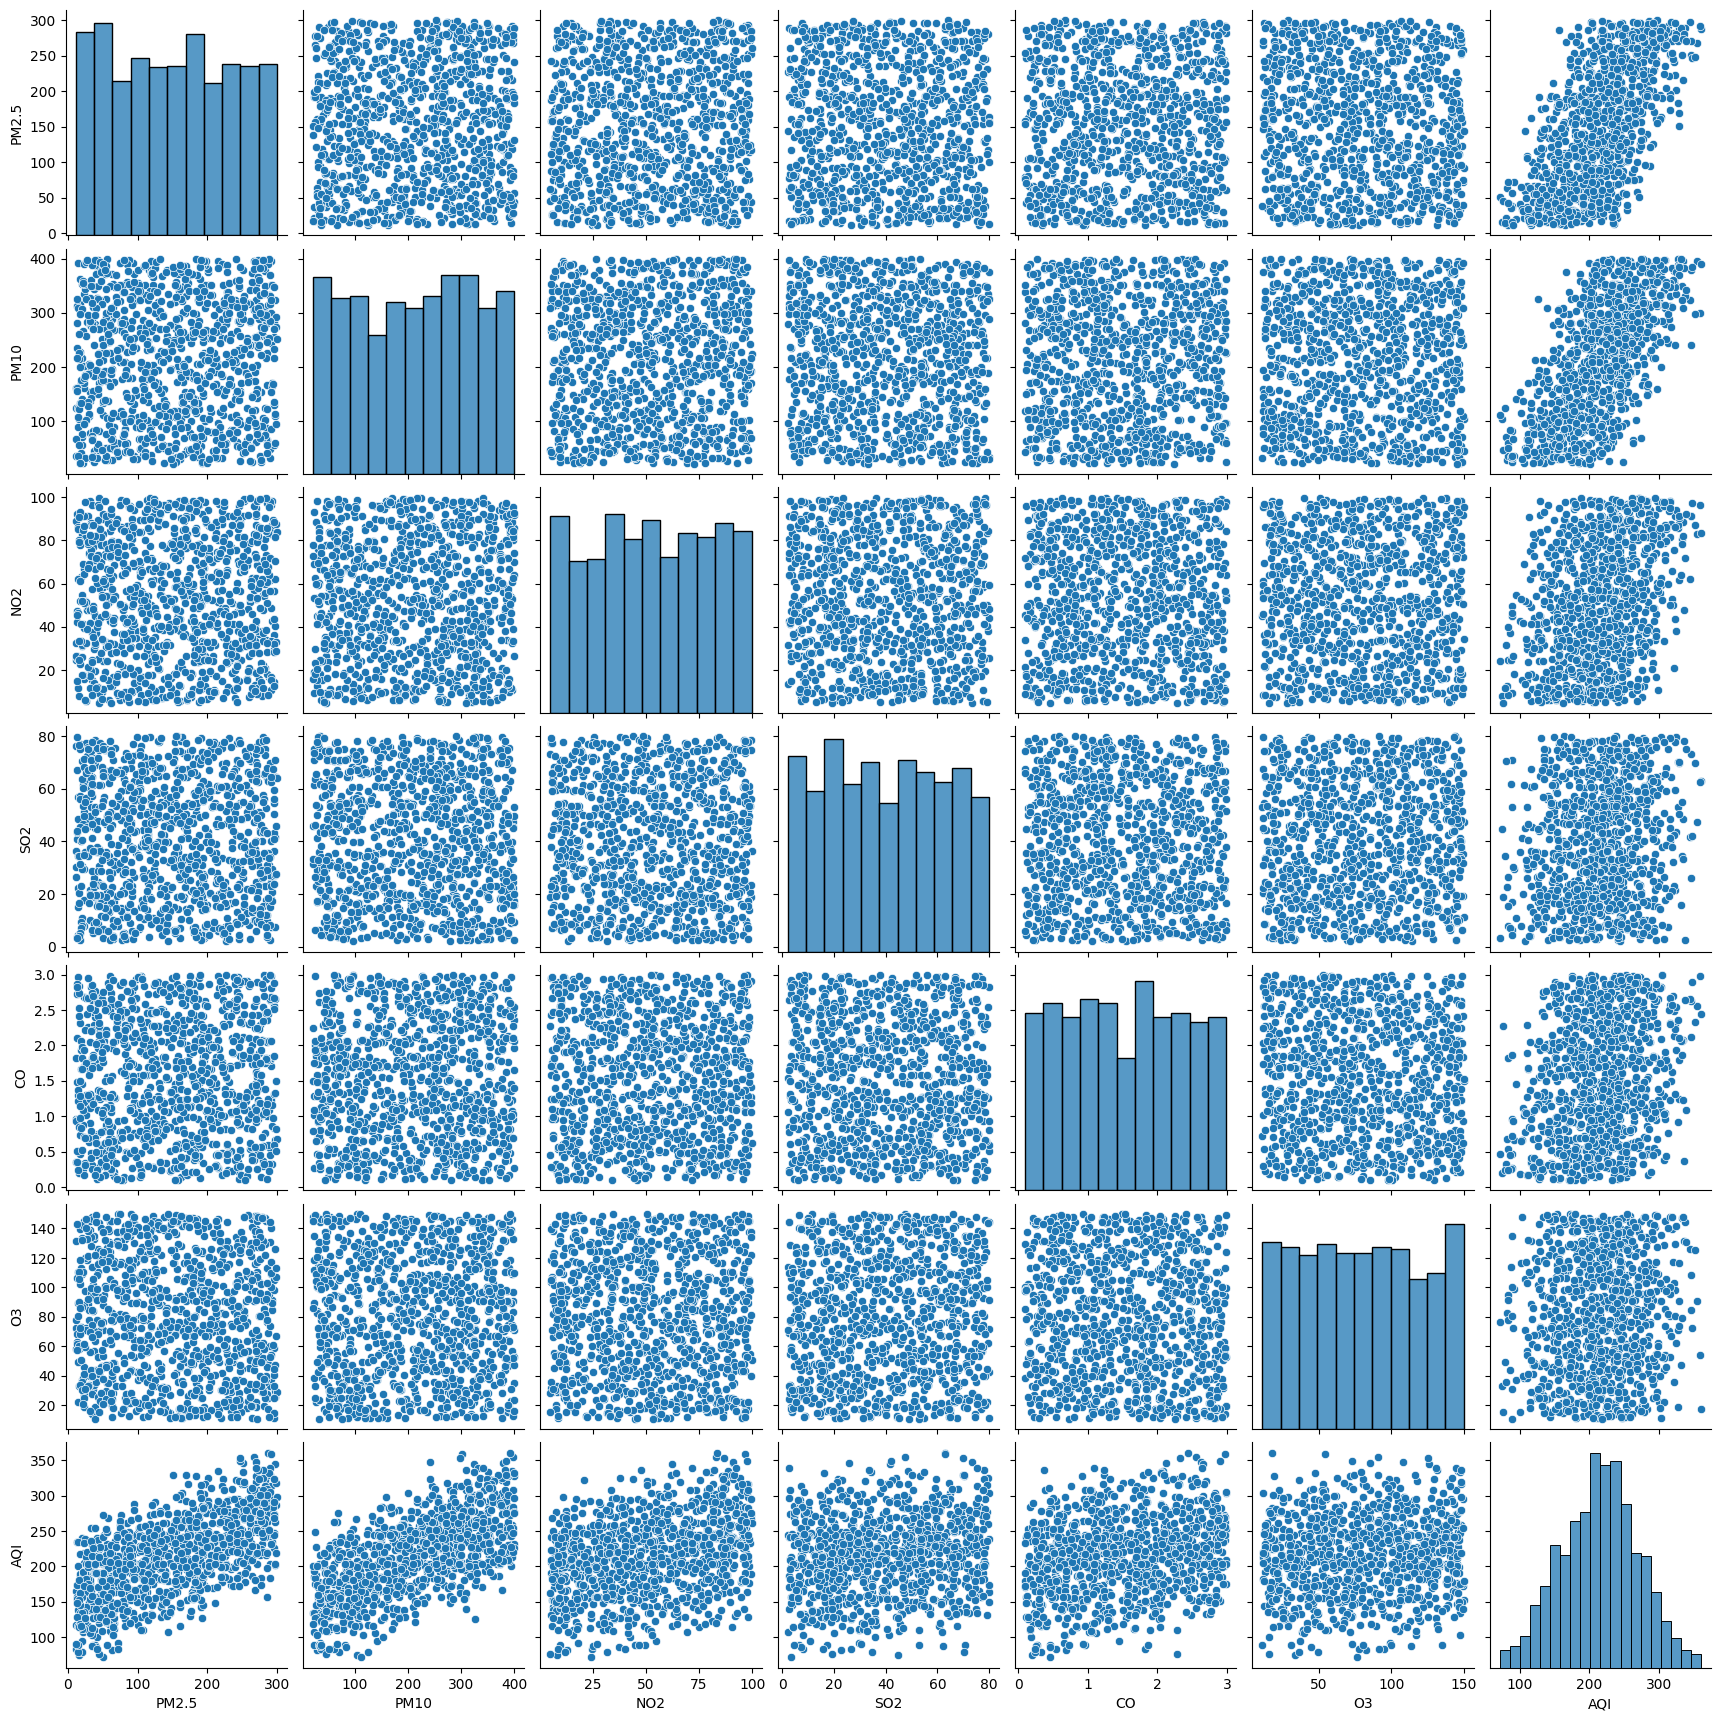


MAE: 8.602098871605333
MSE: 118.51374056557745
RMSE: 10.88640163532365
R2 Score: 0.9624137304913694

Predicted AQI: 103.41901170267462


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
# ---------------------------------------------
# AIR QUALITY INDEX (AQI) PREDICTION PROJECT
# ---------------------------------------------

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------
# 1. Load Dataset
# ---------------------------------------------
# Sample dataset format:
# PM2.5 | PM10 | NO2 | SO2 | CO | O3 | AQI
# You can replace this with your own dataset

data = pd.read_csv("/content/air_quality_1000_rows.csv")
print(data.head())

# ---------------------------------------------
# 2. Check Missing Values
# ---------------------------------------------
print("\nMissing Values:\n", data.isnull().sum())

# Fill missing values
data = data.fillna(data.mean())

# ---------------------------------------------
# 3. Exploratory Data Analysis (EDA)
# ---------------------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(data)
plt.show()

# ---------------------------------------------
# 4. Feature Selection
# ---------------------------------------------
X = data[["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]]   # Input features
y = data["AQI"]                                        # Target

# ---------------------------------------------
# 5. Train Test Split
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------
# 6. Train Model
# ---------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------
# 7. Predict
# ---------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------
# 8. Model Evaluation
# ---------------------------------------------
print("\nMAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# ---------------------------------------------
# 9. Predict AQI for new values
# ---------------------------------------------
sample = np.array([[70, 120, 25, 10, 0.8, 40]])   # Example input
prediction = model.predict(sample)
print("\nPredicted AQI:", prediction[0])